In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

In [9]:
df = pd.read_csv('dataset/household_power_consumption.txt', sep=';', na_values=['?'], low_memory=False)
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df.drop(['Date', 'Time'], axis=1, inplace=True)
df.set_index('Datetime', inplace=True)
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [10]:
# Handle Missing Values
print("Missing values before processing:\n", df.isna().sum())

# For time series, interpolation (filling gaps based on surrounding data) is highly effective.
# 'time' method interpolates based on the time index distance.
df = df.interpolate(method='time')

# If there are missing values at the very beginning of the dataset, interpolation won't catch them.
# We use backfill for those edge cases.
df.bfill(inplace=True) 

print("\nMissing values after processing:\n", df.isna().sum())

Missing values before processing:
 Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Missing values after processing:
 Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


In [11]:
# 1. Prepare the data for Prophet
# We resample to daily averages to make the model run quickly and focus on macro trends
daily_data = pd.DataFrame()
daily_data['Global_active_power'] = df['Global_active_power'].resample('h').mean()

train = daily_data.loc[:'2009']
test = daily_data.loc['2010':]


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def evaluate_model(true, predicted, model = 'ARIMA'):
    mae = mean_absolute_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2 = r2_score(true, predicted)
    print(f"{model} MAE: {mae:.3f}, RMSE: {rmse:.3f}, R² Score: {r2:.3f}")
    return mae, rmse, r2
    

In [13]:
# Prophet needs dataframe with ds and y columns
train_prophet = train.reset_index().rename(columns={'Datetime': 'ds', 'Global_active_power': 'y'})
train_prophet.head()

,ds,y
0,2006-12-16 17:00:00,4.222889
1,2006-12-16 18:00:00,3.632200
2,2006-12-16 19:00:00,3.400233
3,2006-12-16 20:00:00,3.268567
4,2006-12-16 21:00:00,3.056467


In [14]:

# Fit Prophet

model_prophet = Prophet()
model_prophet.fit(train_prophet)

# Create future dataframe
future = model_prophet.make_future_dataframe(periods=len(test), freq='h')
forecast_prophet = model_prophet.predict(future)

# Extract only forecast values
forecast_p = forecast_prophet.set_index('ds')['yhat'][-len(test):]

# Evaluation
mae_prophet, rmse_prophet, r2_prophet = evaluate_model(test, forecast_p, model='Prophet')
# mae_prophet = mean_absolute_error(test, forecast_p)
# rmse_prophet = np.sqrt(mean_squared_error(test, forecast_p))
# r2_prophet = r2_score(test, forecast_p)

# print(f"Prophet MAE: {mae_prophet:.3f}, RMSE: {rmse_prophet:.3f}, R² Score: {r2_prophet:.3f}")

15:16:27 - cmdstanpy - INFO - Chain [1] start processing
15:16:32 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAE: 0.502, RMSE: 0.662, R² Score: 0.267


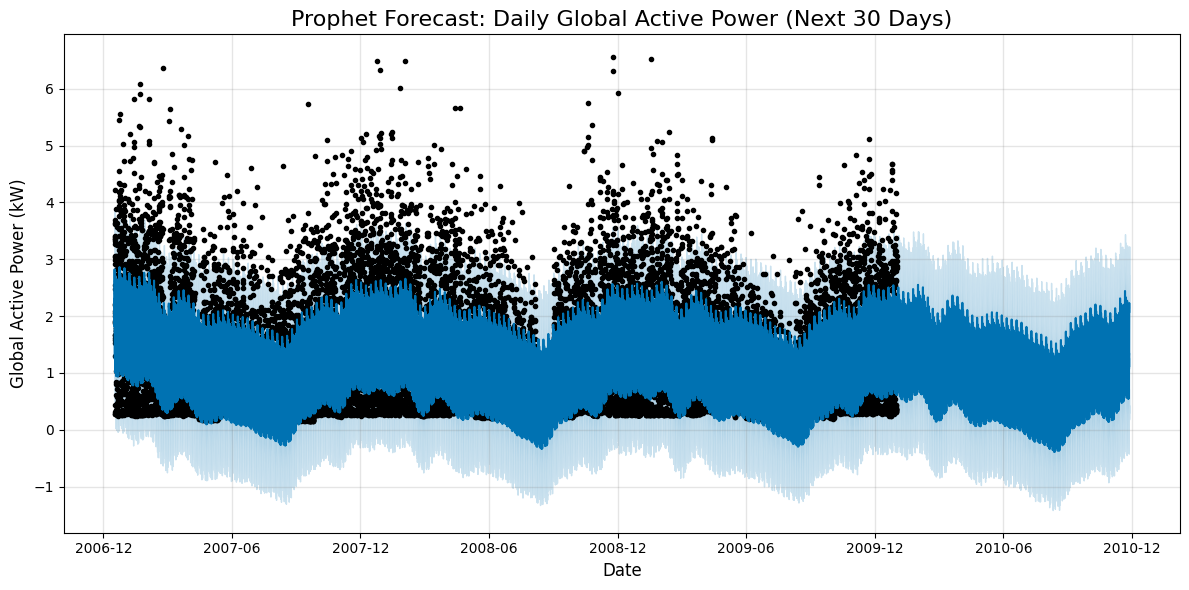

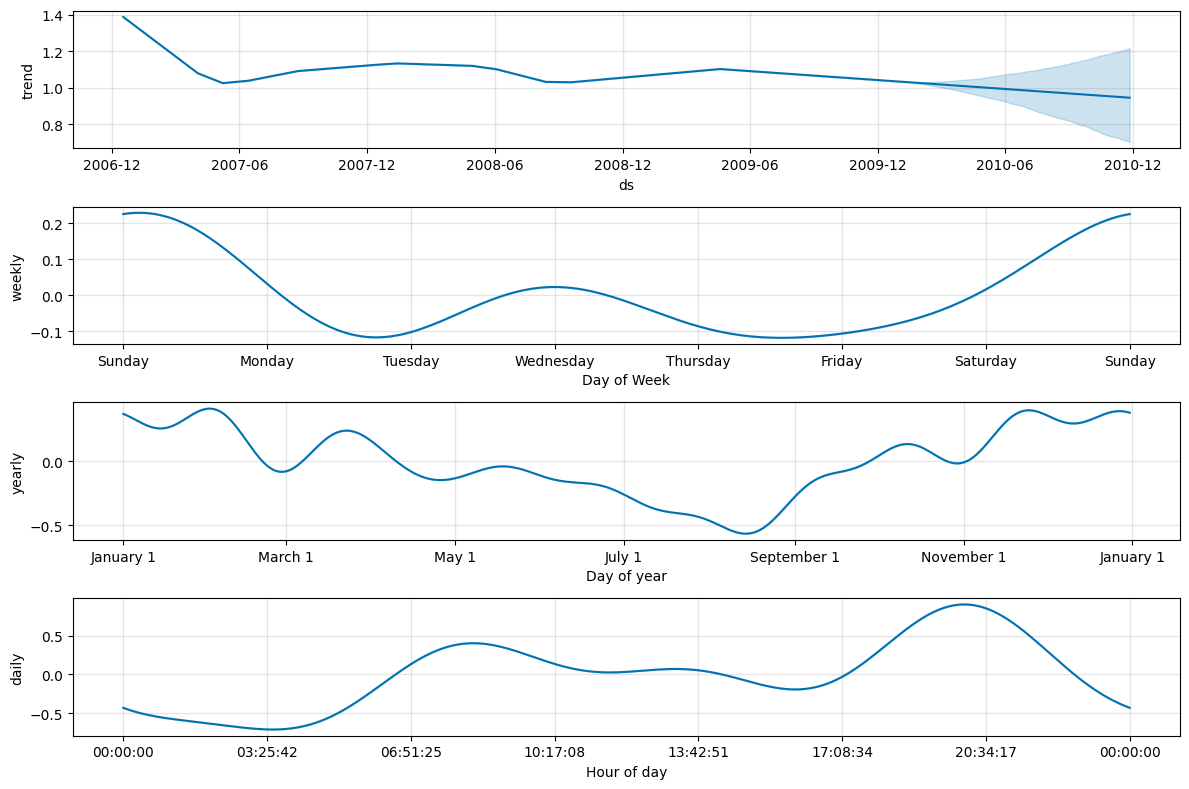

In [15]:
# Plot 1: The Main Forecast
# Black dots are actual historical data, the blue line is the prediction (yhat), 
# and the light blue shaded area is the confidence interval.
fig1 = model_prophet.plot(forecast_prophet, figsize=(12, 6))
plt.title('Prophet Forecast: Daily Global Active Power (Next 30 Days)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Global Active Power (kW)', fontsize=12)
plt.tight_layout()
plt.show()

# Plot 2: The Forecast Components
# This breaks down the forecast into Trend, Weekly, and Yearly patterns
fig2 = model_prophet.plot_components(forecast_prophet, figsize=(12, 8))
plt.tight_layout()
plt.show()

In [16]:
import xgboost as xgb
df_xgb = daily_data
df_xgb['hour'] = df_xgb.index.hour
df_xgb['day'] = df_xgb.index.day
df_xgb['weekday'] = df_xgb.index.weekday
df_xgb['month'] = df_xgb.index.month
for i in range(1, 25):
    df_xgb[f'lag_{i}'] = df_xgb['Global_active_power'].shift(i)

df_xgb.dropna(inplace=True)

X = df_xgb.drop('Global_active_power', axis=1)
y = df_xgb['Global_active_power']
X_train = X[:'2009']
y_train = y[:'2009']
X_test = X['2010':]
y_test = y['2010':]

# Train XGBoost
xgb_model = xgb.XGBRegressor()
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)


# Evaluation
mae_xgb, rmse_xgb, r2_xgb = evaluate_model(y_test, y_pred_xgb, model='XGBoost')
# mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
# rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
# r2_xgb = r2_score(y_test, y_pred_xgb)

# print(f"XGBoost MAE: {mae_xgb:.3f}, RMSE: {rmse_xgb:.3f}, R² Score: {r2_xgb:.3f}")

XGBoost MAE: 0.347, RMSE: 0.497, R² Score: 0.588


In [17]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(train)
print(f"ADF p-value: {result[1]:.4f}")

ADF p-value: 0.0000


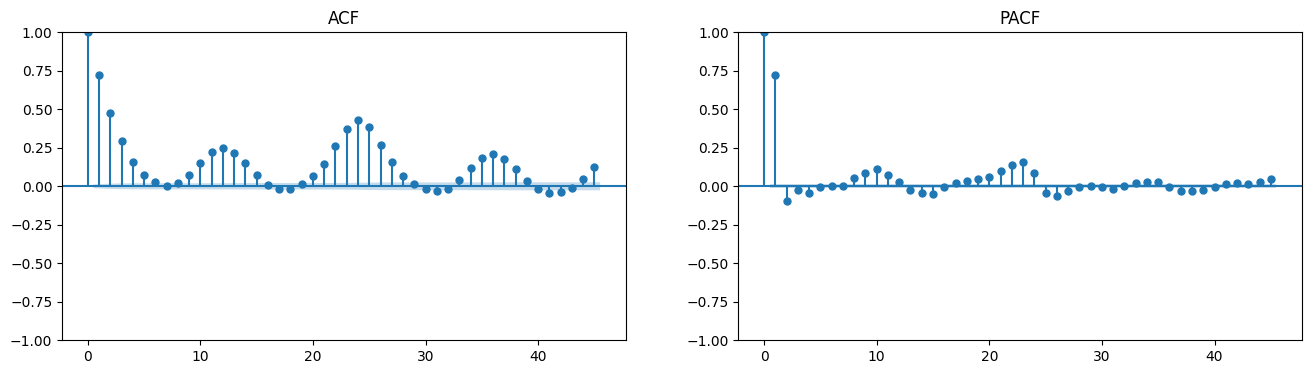

In [18]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

stationary_train = train.dropna() 

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(stationary_train, ax=axes[0], title="ACF")
plot_pacf(stationary_train, ax=axes[1], title="PACF")
plt.show()

In [19]:
# from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm

# Auto-ARIMA will automatically figure out p, d, and q for you!
auto_model = pm.auto_arima(train, 
                           start_p=0, start_q=0,
                           max_p=5, max_q=5, # Maximum bounds
                           m=1,              # Set to >1 if you have seasonality
                           d=None,           # Let it find 'd' automatically
                           trace=True,       # Shows the search process
                           error_action='ignore',  
                           suppress_warnings=True, 
                           stepwise=True)    # Uses a smart search algorithm

print(auto_model.summary())
forecast_arima = auto_model.predict(n_periods=len(test))

# Evaluation
mae_arima, rmse_arima, r2_arima = evaluate_model(test, forecast_arima, model='ARIMA')
# mae_arima = mean_absolute_error(test, forecast_arima)
# rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))
# r2_arima = r2_score(test, forecast_arima)

# # Print all scores
# print(f"ARIMA MAE: {mae_arima:.3f}, RMSE: {rmse_arima:.3f}, R² Score: {r2_arima:.3f}")

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=56182.973, Time=1.48 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=56086.843, Time=0.87 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=56052.513, Time=1.75 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=56180.973, Time=0.32 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=10.53 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=55264.908, Time=2.86 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=15.29 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=52745.854, Time=13.09 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=20.16 sec
 ARIMA(0,1,4)(0,0,0)[0] intercept   : AIC=inf, Time=15.14 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : AIC=inf, Time=22.39 sec
 ARIMA(0,1,3)(0,0,0)[0]             : AIC=52743.862, Time=2.29 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=55262.909, Time=1.18 sec
 ARIMA(1,1,3)(0,0,0)[0]             : AIC=inf, Time=4.23 sec
 ARIMA(0,1,4)(0,0,0)[0]             : AIC=inf, Ti

In [20]:
print("📋 Forecasting Model Performance:\n")
print(f"ARIMA    → MAE: {mae_arima:.3f}, RMSE: {rmse_arima:.3f}, R²: {r2_arima:.3f}")
print(f"Prophet  → MAE: {mae_prophet:.3f}, RMSE: {rmse_prophet:.3f}, R²: {r2_prophet:.3f}")
print(f"XGBoost  → MAE: {mae_xgb:.3f}, RMSE: {rmse_xgb:.3f}, R²: {r2_xgb:.3f}")

📋 Forecasting Model Performance:

ARIMA    → MAE: 0.810, RMSE: 0.940, R²: -0.474
Prophet  → MAE: 0.502, RMSE: 0.662, R²: 0.267
XGBoost  → MAE: 0.347, RMSE: 0.497, R²: 0.588


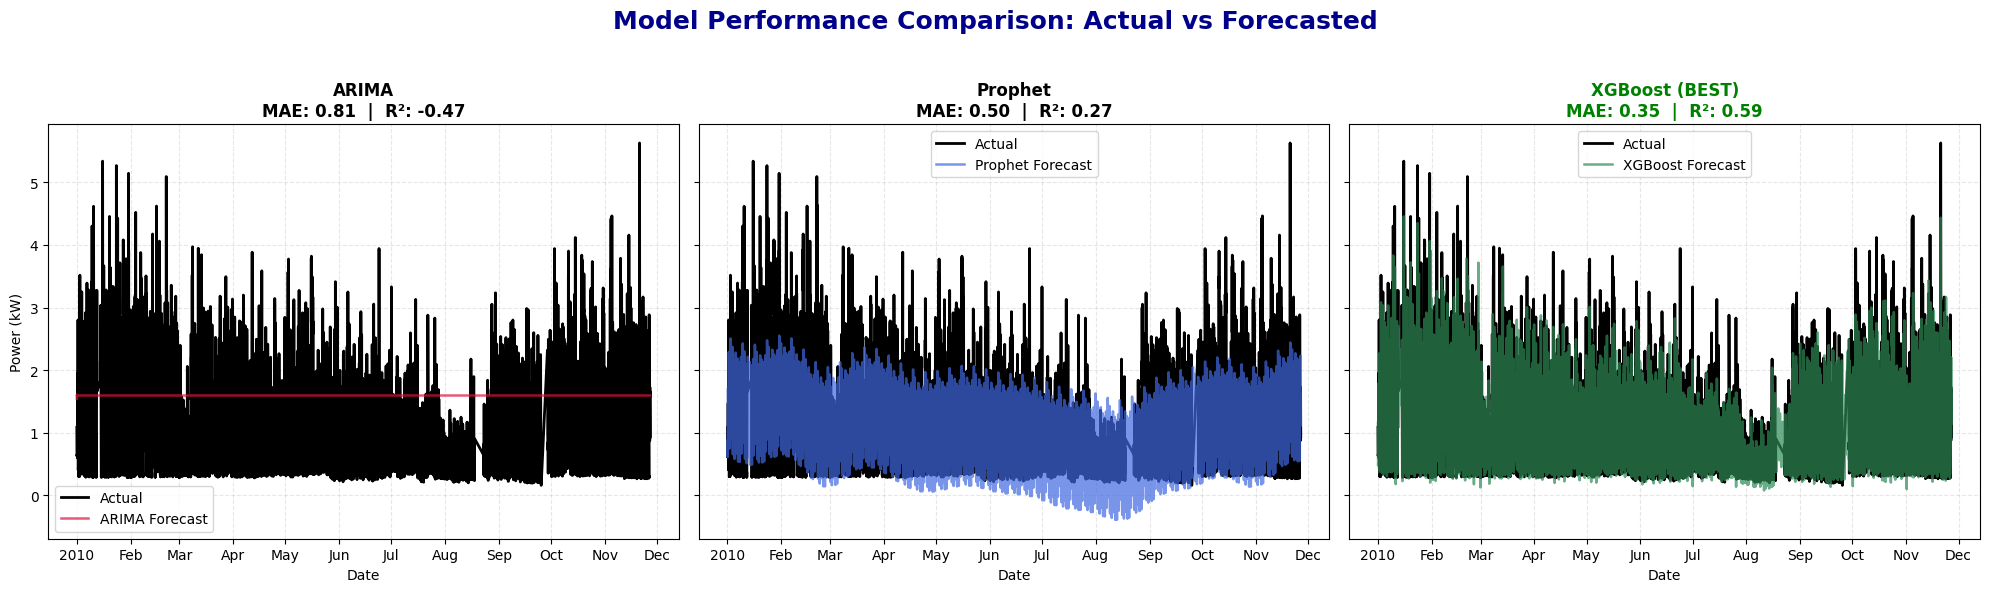

In [21]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Extract actual test values
if isinstance(test, pd.DataFrame):
    test_actual = test['Global_active_power']
else:
    test_actual = test

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
fig.suptitle('Model Performance Comparison: Actual vs Forecasted', fontsize=18, fontweight='bold', color='darkblue')

# Common styling variables
actual_color = 'black'
alpha_forecast = 0.7

# Plot 1: ARIMA
axes[0].plot(test_actual.index, test_actual.values, label='Actual', color=actual_color, linewidth=2)
axes[0].plot(test_actual.index, forecast_arima, label='ARIMA Forecast', color='crimson', alpha=alpha_forecast, linewidth=1.8)
axes[0].set_title(f'ARIMA\nMAE: {mae_arima:.2f}  |  R²: {r2_arima:.2f}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Power (kW)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.3)

# Plot 2: Prophet
axes[1].plot(test_actual.index, test_actual.values, label='Actual', color=actual_color, linewidth=2)
axes[1].plot(test_actual.index, forecast_p, label='Prophet Forecast', color='royalblue', alpha=alpha_forecast, linewidth=1.8)
axes[1].set_title(f'Prophet\nMAE: {mae_prophet:.2f}  |  R²: {r2_prophet:.2f}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.3)

# Plot 3: XGBoost
axes[2].plot(y_test.index, y_test.values, label='Actual', color=actual_color, linewidth=2)
axes[2].plot(y_test.index, y_pred_xgb, label='XGBoost Forecast', color='seagreen', alpha=alpha_forecast, linewidth=1.8)
axes[2].set_title(f'XGBoost (BEST)\nMAE: {mae_xgb:.2f}  |  R²: {r2_xgb:.2f}', fontsize=12, fontweight='bold', color='green')
axes[2].set_xlabel('Date')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.3)

# Improve x-axis formatting
for ax in axes:
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

# Final layout
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for suptitle
plt.show()
